# **Visualising Feature Learning in Convolutional Neural Networks**

**Name:** Olasupo Abimbola \
**Student ID:** 24115208  \
**Module:** Machine Learning and Neural Network \
**GitHub Repository:** https://github.com/ao25aaf/Visualizing-Feature-Learning-in-CNNs.git

## Introduction

In this notebook, we would examine how convolutional neural networks learn hierarchical features from images of different complexities. Our focus would be on the feature map visualisation of two datasets, namely; MNIST and CIFAR-10.

We aim to compare the maps of the two dataset and show how early convolutionl layers tend to take-in simple patterns, such as; curves, edges, strokes... while deeper layers learn more abstract representations (such as shape). We would exemplify the effect of complexity on the features a CNN learns by comparing the MNIST and CIFAR-10 datasets.

1. What is CNN?

 "Convolutional Neural Network (CNN) is a specialized feedforward artificial neural network that efficiently learns spatial or temporal patterns through convolutional filters. It excels at extracting hierarchical features from grid structured data, especially images, by leveraging parameter sharing and local connectivity."


 *Source: Arm (n.d.) What is Convolutional Neural Network? Available [here](https://www.arm.com/glossary/convolutional-neural-network)*

 On the otherhand, feature learning refers to an automatic process by which a model learns key patterns, structures, or characteristics (often called *features*) from raw data. Early layers learn simple features, while deeper/hidden layers integrates these into complex structures.


 2. Objective

 Our ultimate focus is **feature learning** in CNNs, rather than explaining every aspect of CNNs. Hence, this notebook would investigate how internal feature maps change accross layers.

 To examine these clearly, we have used the same CNN architecture for both the MNIST and CIFAR-10 Datasets. Our aim is that comparison amongs the two  would help reveal how image complexity affects learned representations.

### **Import necessary Libraries**

In [95]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.datasets import mnist, cifar10
import os
os.makedirs("images", exist_ok=True)

We have imported the above libraries to help us carryout our objectives. NumPy would help with our numerical operations, Matplotlib with our plots (images, and feature maps), Tensorflow/Keras will help in building and training CNNs, while the os module is used to create a directory for saving our imges and figures throughout this notebook.

### **Load and preprocess the MNIST and CIFAR-10 Datasets**

Here, we load both of our datasets and examine their
shapes and sample images.

MNIST_Train:  (60000, 28, 28)
MNIST_Test:  (10000, 28, 28)


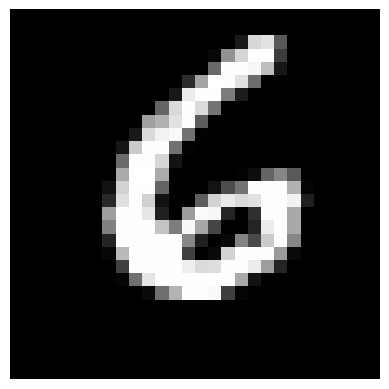

Label(y): 6


In [96]:
# Loading the imported MNIST Dataset
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist\
.load_data()

# Checking the shape of the MNIST train and test data
print("MNIST_Train: ", x_train_mnist.shape)
print("MNIST_Test: ", x_test_mnist.shape)

# Inspecting the 91st train data (random selection)
plt.imshow(x_train_mnist[90], cmap='gray')
plt.axis('off')
plt.savefig("images/mnist_example.png", bbox_inches='tight')
plt.show()
plt.close()

# Printing corresponding image label
print(f"Label(y): {y_train_mnist[90]}")

It is observable that MNIST images are visually simple and easy to interpret. They consist of clearly graded strokes and shape showing a grayscale handwritten digit.

CIFAR-10_Train:  (50000, 32, 32, 3)
CIFAR-10_Test:  (10000, 32, 32, 3)


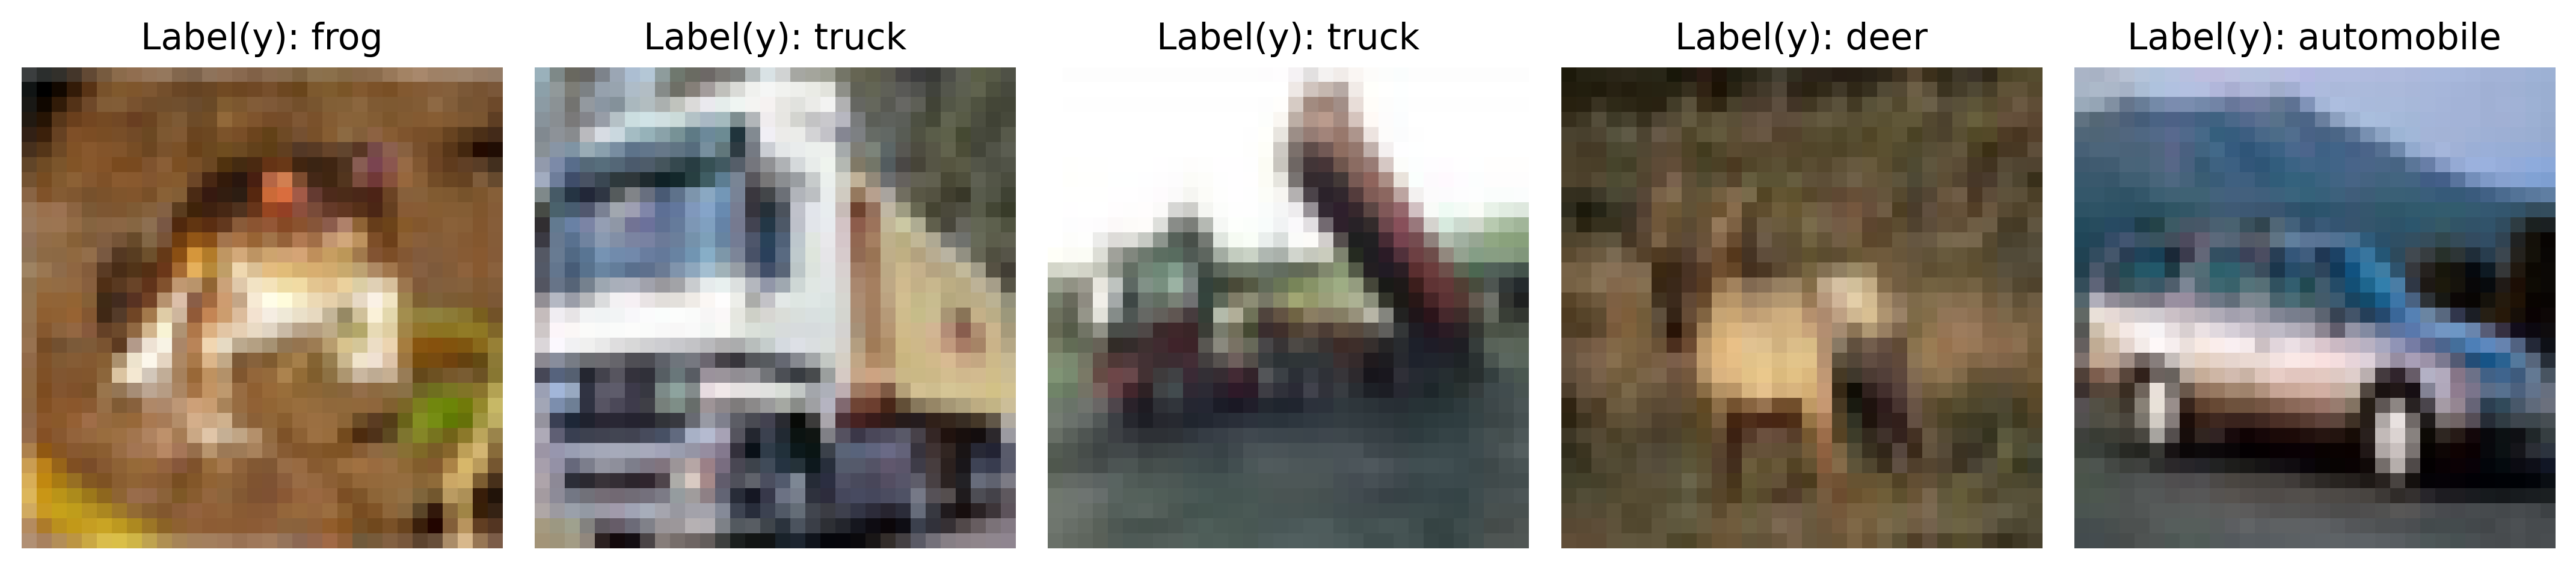

In [97]:
# Loading the imported CIFAR-10 dataset

(x_train_cifar, y_train_cifar),(x_test_cifar, y_test_cifar) = cifar10\
.load_data()

# Checking the shape of the CIFAR-10 train and test data
print("CIFAR-10_Train: ", x_train_cifar.shape)
print("CIFAR-10_Test: ", x_test_cifar.shape)

# Inputting CIFAR-10 actual labels
cifar10_labels = ['airplane','automobile', 'bird','cat','deer','dog',\
                  'frog','horse','ship','truck']

# Inspecting multiple training data
plt.figure(figsize=(12,5), dpi=360)
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(x_train_cifar[i])
  plt.title(f"Label(y): {cifar10_labels[y_train_cifar[i][0]]}")
  plt.axis('off')

plt.tight_layout()
plt.savefig("images/cifar_example.png", bbox_inches='tight')
plt.show()
plt.close()

We can observe from above that the CIFAR-10 images contain small coloured real-word images of objects such as frog, truck and so on, howbeit; blury, due to the low pixel size (32 by 32). It is worthy of note that the CIFAR-10 dataset consists of predefined classes, as articulated in the initial dataset documentation (Krizhevsky et al.), [here](https://www.cs.toronto.edu/~kriz/cifar.html). These classes are as follows in its hirarchy:


*   airplane
*   automobile
*   bird
*   cat
*   deer
*   dog
*   frog
*   horse
*   ship
*   truck

Given our datasets return numerical labels ranging from 0 - 9, we define a mapping from label indices to class names for interpretability.

It's also observable outrightly from the above, that the images are more complex compared to the grayscaled images of the MNIST dataset. Here we can notice more texture and background information.


---

Below we preporocess the data before training so they can be usable by the CNN. Our preprocessing would include; normalizing pixel values for both datasets and reshaping only our MNIST dataset to include channel dimension.

In [98]:
# Normalizing pixel values (converting "0 - 255" to "0 - 1")
x_train_mnist = x_train_mnist / 255.0
x_test_mnist = x_test_mnist / 255.0

# Reshaping datasets for channel inclusion
x_train_mnist = x_train_mnist.reshape(-1, 28, 28, 1)
x_test_mnist = x_test_mnist.reshape(-1, 28, 28, 1)

# Confirming new shape dimensions
print("MNIST_Train: ", x_train_mnist.shape)
print("MNIST_Test: ", x_test_mnist.shape)

MNIST_Train:  (60000, 28, 28, 1)
MNIST_Test:  (10000, 28, 28, 1)


In [99]:
# Normalizing pixel values (converting "0 - 255" to "0 - 1")
x_train_cifar = x_train_cifar / 255.0
x_test_cifar = x_test_cifar / 255.0

### **Build resuable CNN Function**

We proceed to building our CNN architecture. The smae architecture is used for both datasets so that the contrast in feature learning can be grossly ascribed to dataset complexity and not the model design.

The network contains: 2 convolutional layers, max-pool layers, and a dense classifier for the final prediction.

In [100]:
def cnn_function(input_shape, num_classes):
  reusable_model = models.Sequential()

  # 1st convolutional layer
  reusable_model.add(layers.Conv2D(16,(3,3), activation='relu',\
                                    input_shape=input_shape))
  reusable_model.add(layers.MaxPooling2D((2,2)))

  # 2nd convolutional layer
  reusable_model.add(layers.Conv2D(32,(3,3), activation='relu'))
  reusable_model.add(layers.MaxPooling2D((2,2)))

  # Flatten and dense layers
  reusable_model.add(layers.Flatten())
  reusable_model.add(layers.Dense(64, activation='relu'))
  reusable_model.add(layers.Dense(num_classes, activation='softmax'))

  return reusable_model

### Why this **architeture**?

We built this model to be small and easily interpretable intentionally. Our goal is to understand how learned features evolve accross layers and not to particularly achieve cutting-edge accuracy.

### **Train model on MNIST Dataset**

In [101]:
# Using the reusable CNN function for MNIST
mnist_reusable_model = cnn_function(input_shape=(28,28,1), num_classes=10)

# Compiling the model
mnist_reusable_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Model Structure
mnist_reusable_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 26, 26, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 13, 13, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 11, 11, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 5, 5, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 800)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 64)             │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 56,714 (221.54 KB)

 Trainable params: 56,714 (221.54 KB)

 Non-trainable params: 0 (0.00 B)

In [102]:
# Training MNIST Dataset

history_mnist = mnist_reusable_model.fit(
    x_train_mnist,
    y_train_mnist,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.9337 - loss: 0.2227 - val_accuracy: 0.9792 - val_loss: 0.0724
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9790 - loss: 0.0672 - val_accuracy: 0.9868 - val_loss: 0.0453
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9844 - loss: 0.0492 - val_accuracy: 0.9858 - val_loss: 0.0487
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9890 - loss: 0.0371 - val_accuracy: 0.9887 - val_loss: 0.0448
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9904 - loss: 0.0301 - val_accuracy: 0.9898 - val_loss: 0.0432
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9919 - loss: 0.0259 - val_accuracy: 0.9895 - val_loss: 0.0388
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9930 - loss: 0.0218 - val_accuracy: 0.9897 - val_loss: 0.0405
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9940 - loss: 0.0181 - val_accuracy: 0.

We can see from above that the model attains very high accuracy rate on the MNIST dataset which implies that it has substantially learnt meaningful features from the data, making it a useful baseline for our feature maps visualisation.

In [103]:
# Evaluating on the MNIST test dataset

mnist_test_loss, mnist_test_accuracy = mnist_reusable_model.evaluate(x_test_mnist, y_test_mnist)

print(f"MNIST Test Loss: ", mnist_test_loss)
print(f"MNIST Test accuracy: ", mnist_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9882 - loss: 0.0399
MNIST Test Loss:  0.039868876338005066
MNIST Test accuracy:  0.9882000088691711


### **Train model on CIFAFR-10 Dataset**

In [104]:
# Using the reusable CNN function for CIFAR-10
cifar_reusable_model = cnn_function(input_shape=(32,32,3), num_classes=10)

# Compiling the model
cifar_reusable_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Model Structure
cifar_reusable_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_22 (Conv2D)              │ (None, 30, 30, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 15, 15, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 13, 13, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,530 (310.66 KB)

 Trainable params: 79,530 (310.66 KB)

 Non-trainable params: 0 (0.00 B)

In [105]:
# Training CIFAR-10 Dataset

history_cifar = cifar_reusable_model.fit(
    x_train_cifar,
    y_train_cifar,
    epochs=10,
    batch_size=64,
    validation_split=0.1
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.4227 - loss: 1.5977 - val_accuracy: 0.5188 - val_loss: 1.3617
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5393 - loss: 1.3016 - val_accuracy: 0.5722 - val_loss: 1.2229
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5843 - loss: 1.1797 - val_accuracy: 0.5992 - val_loss: 1.1492
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6165 - loss: 1.0959 - val_accuracy: 0.6226 - val_loss: 1.0740
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6367 - loss: 1.0400 - val_accuracy: 0.6278 - val_loss: 1.0803
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6541 - loss: 0.9885 - val_accuracy: 0.6336 - val_loss: 1.0364
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6708 - loss: 0.9451 - val_accuracy: 0.6296 - val_loss: 1.0408
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6849 - loss: 0.9082 - val_accuracy: 0.

We can notice here that compared to the MNIST the model performed evidently worse. This we can say is expected as it reflects the complex nature of the images. The lower performance suggests that the model must learn more difficult and less visually obvious features.

The purpose of this step is actually not just classification, but to observe how the complexity affect how the CNN learns features under diverse visual task.

In [106]:
# Evaluating on the cifar-10 test dataset

cifar_test_loss, cifar_test_accuracy = cifar_reusable_model.evaluate\
 (x_test_cifar, y_test_cifar)

print(f"CIFAR-10 Test Loss: ", cifar_test_loss)
print(f"CIFAR-10 Test accuracy: ", cifar_test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6635 - loss: 0.9728
CIFAR-10 Test Loss:  0.9728471636772156
CIFAR-10 Test accuracy:  0.6635000109672546


### **Feature Map Extraction**

In [107]:
# Creating a model which outputs intermediate layers
# MNIST
mnist_layer_outputs = [
    mnist_reusable_model.layers[0].output,
    mnist_reusable_model.layers[2].output
]

mnist_feature_map_model = models.Model(
    inputs = mnist_reusable_model.inputs,
    outputs = mnist_layer_outputs
)

# CIFAR-10
cifar_layer_outputs = [
    cifar_reusable_model.layers[0].output,
    cifar_reusable_model.layers[2].output
]

cifar_feature_map_model = models.Model(
    inputs = cifar_reusable_model.inputs,
    outputs = cifar_layer_outputs
)

We will now be selecting one sample image from each dataset in order to examine feature learning directly. We would then pass them through intermediate layers of trained CNN such that we can clearly visualize their feature maps.

In [108]:
# Passing one MNIST dataset through the MNIST intermediate model

# Selecting one test image
mnist_test_image = x_test_mnist[0]

# Adding batch dimensions
mnist_test_image = np.expand_dims(mnist_test_image, axis=0)

# Extracting features map
mnist_feature_maps = mnist_feature_map_model.predict(mnist_test_image)

# Checking shsape of extracted feature maps
print(f" 1st convolutional layer feature map MNIST: ",
      mnist_feature_maps[0].shape)
print(f" 2nd convolutional layer feature map MNIST: ",
      mnist_feature_maps[1].shape)

# Passing one CIFAR-10 dataset through the CIFAR-10 intermediate model

# Selecting one test image
cifar_test_image = x_test_cifar[0]

# Adding batch dimensions
cifar_test_image = np.expand_dims(cifar_test_image, axis=0)

# Extracting features map
cifar_feature_maps = cifar_feature_map_model.predict(cifar_test_image)

# Checking shsape of extracted feature maps
print(f" 1st convolutional layer feature map CIFAR-10: ",
      cifar_feature_maps[0].shape)
print(f" 2nd convolutional layer feature map CIFAR-10: ",
      cifar_feature_maps[1].shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step
 1st convolutional layer feature map MNIST:  (1, 26, 26, 16)
 2nd convolutional layer feature map MNIST:  (1, 11, 11, 32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step
 1st convolutional layer feature map CIFAR-10:  (1, 30, 30, 16)
 2nd convolutional layer feature map CIFAR-10:  (1, 13, 13, 32)


The following plots show the original MNIST image and the feature maps produced by the first and second convolutional layers.

For MNIST, the first-layer feature maps are expected to highlight simple structures such as edges, strokes, and curves. The second-layer feature maps should show more combined and abstract patterns.

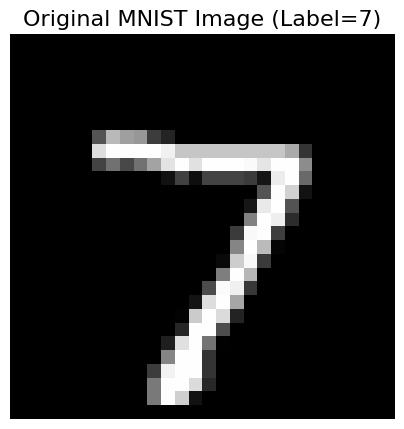

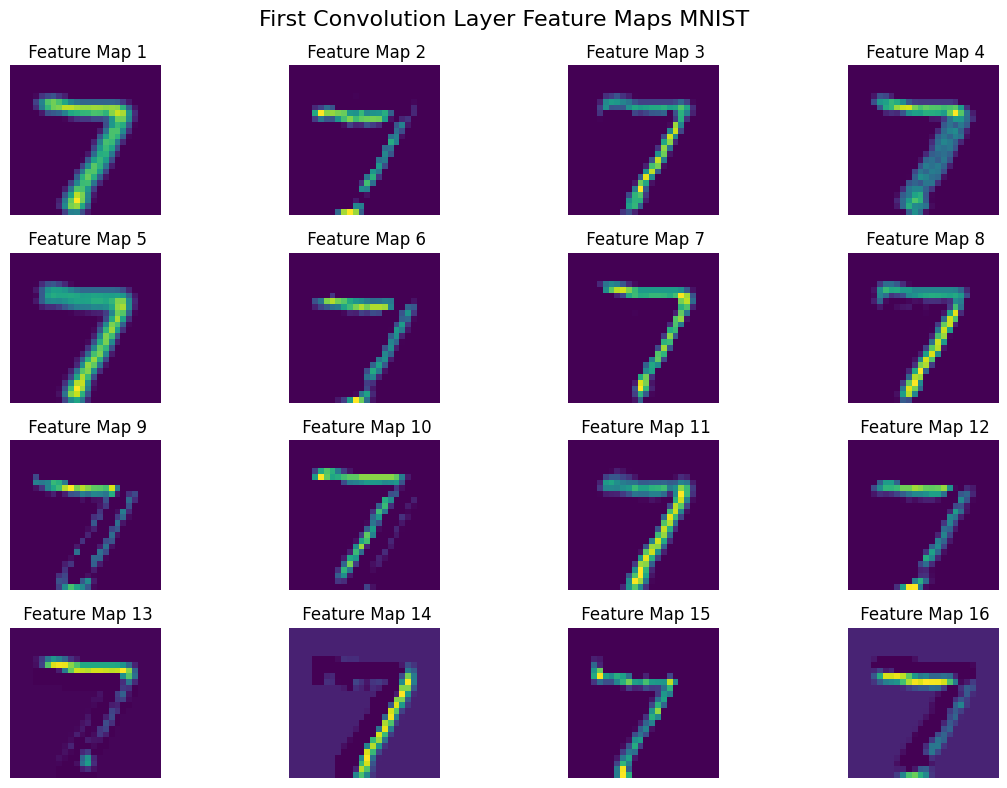

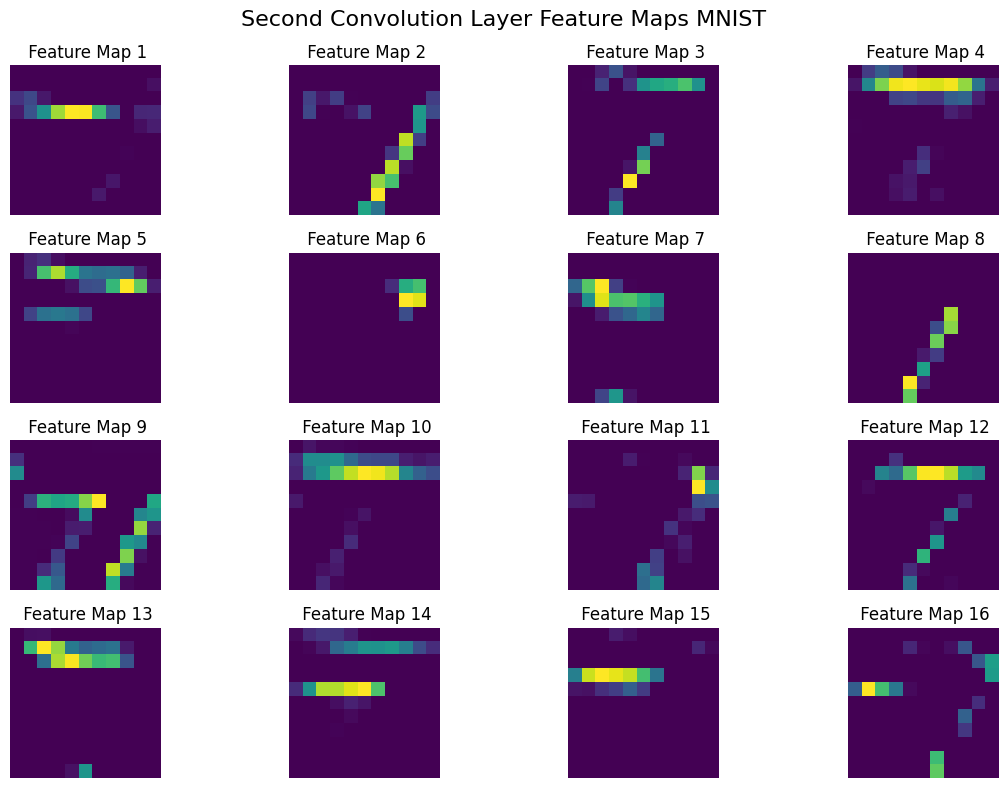

In [109]:
# Plotting Feature Maps MNIST

# Visualizing one Original MNIST image
plt.figure(figsize=(5,5), dpi=100)
plt.imshow(x_test_mnist[0].squeeze(), cmap='gray')
plt.title(f"Original MNIST Image (Label={y_test_mnist[0]})", fontsize=16)
plt.axis('off')
plt.savefig("images/original_test_mnist.png", bbox_inches='tight')
plt.show()
plt.close()

# Plotting the 1st convolution layer feature maps MNIST
plt.figure(figsize=(12,8), dpi=100)

for i in range(16):
  plt.subplot(4, 4, i +1)
  plt.imshow(mnist_feature_maps[0][0, :, :, i], cmap='viridis')
  plt.title(f" Feature Map {i+1}")
  plt.axis('off')

plt.suptitle("First Convolution Layer Feature Maps MNIST", fontsize=16)
plt.tight_layout()
plt.savefig("images/mnist_layer1.png", bbox_inches='tight')
plt.show()
plt.close()

# Plotting the 2nd convolution layer feature maps MNIST
plt.figure(figsize=(12,8), dpi=100)

for i in range(16):
  plt.subplot(4, 4, i +1)
  plt.imshow(mnist_feature_maps[1][0, :, :, i], cmap='viridis')
  plt.title(f" Feature Map {i+1}")
  plt.axis('off')

plt.suptitle("Second Convolution Layer Feature Maps MNIST", fontsize=16)
plt.tight_layout()
plt.savefig("images/mnist_layer2.png", bbox_inches='tight')
plt.show()
plt.close()

The feature maps from the first convolutional layer are relatively easy to interpret, with several maps clearly responding to edges and strokes in the digit. In the second convolutional layer, the activations become more abstract, suggesting that the model is combining simpler features into more meaningful digit-related structures.


---


The following plots show the feature maps generated from a CIFAR-10 image. Compared with MNIST, these maps are expected to be less directly interpretable because the input images are more complex and contain colour, texture, and background variation.

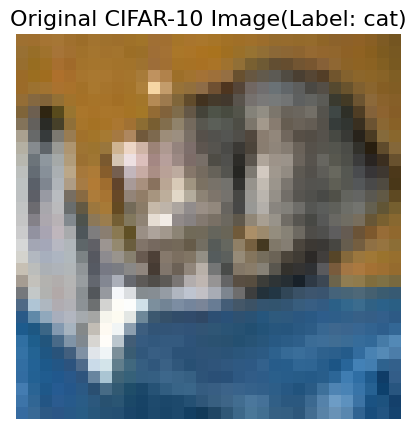

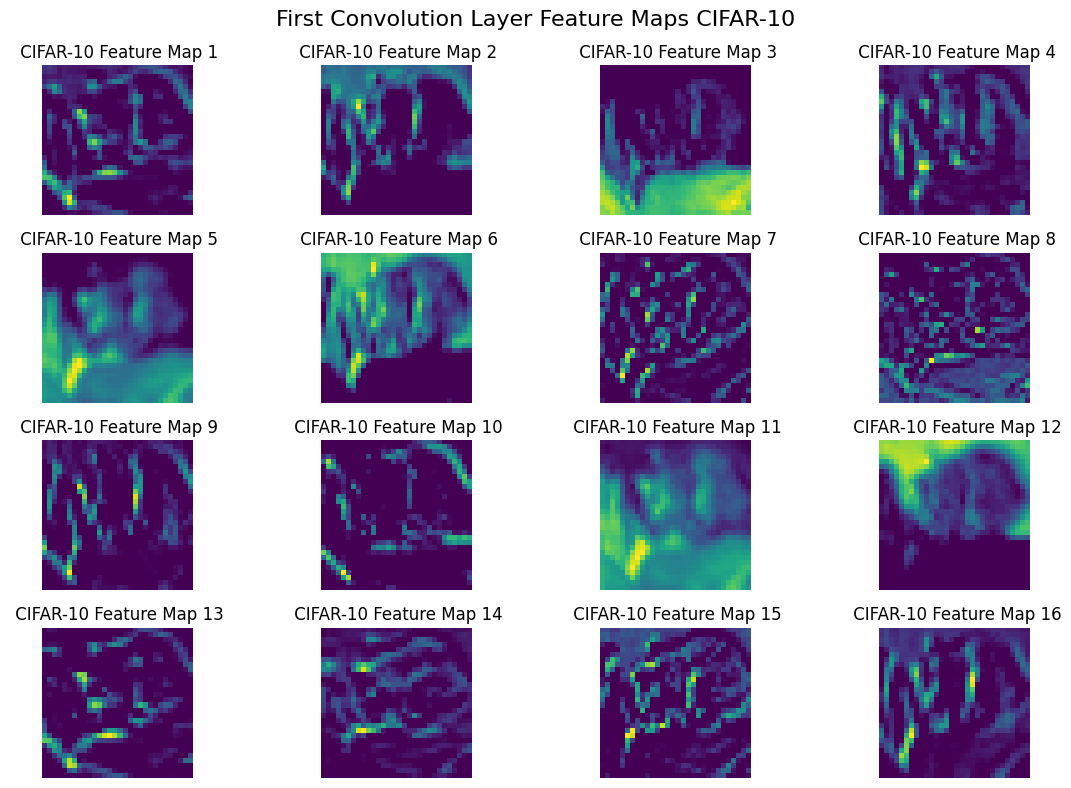

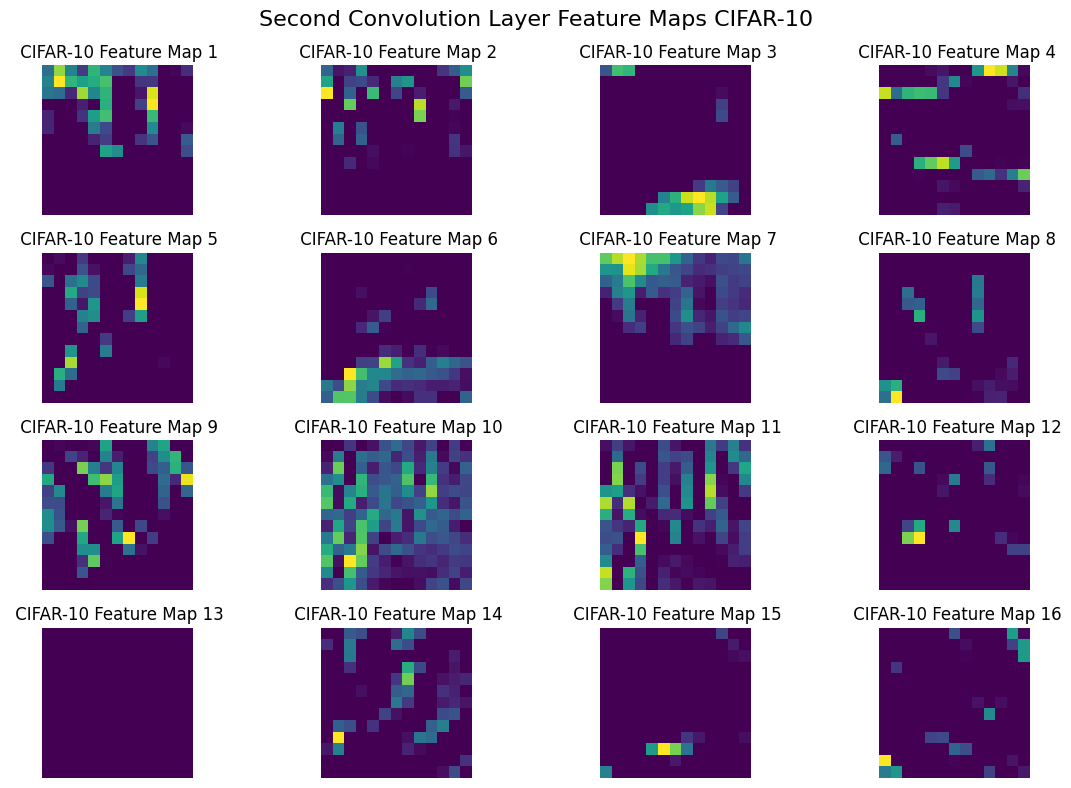

In [110]:
# Plotting Feature Maps CIFAR-10

# Visualizing one Original CIFAR-10 image
plt.figure(figsize=(5,5), dpi=100)
plt.imshow(x_test_cifar[0].squeeze(), cmap='gray')
plt.title(f"Original CIFAR-10 Image\
(Label: {cifar10_labels[y_test_cifar[0][0]]})", fontsize=16)
plt.axis('off')
plt.savefig("images/original_test_cifar.png", bbox_inches='tight')
plt.show()
plt.close()

# Plotting the 1st convolution layer feature maps CIFAR-10
plt.figure(figsize=(12,8), dpi=100)

for i in range(16):
  plt.subplot(4, 4, i +1)
  plt.imshow(cifar_feature_maps[0][0, :, :, i], cmap='viridis')
  plt.title(f" CIFAR-10 Feature Map {i+1}")
  plt.axis('off')

plt.suptitle("First Convolution Layer Feature Maps CIFAR-10", fontsize=16)
plt.tight_layout()
plt.savefig("images/cifar_layer1.png", bbox_inches='tight')
plt.show()
plt.close()

# Plotting the 2nd convolution layer feature maps CIFAR-10
plt.figure(figsize=(12,8), dpi=100)

for i in range(16):
  plt.subplot(4, 4, i +1)
  plt.imshow(cifar_feature_maps[1][0, :, :, i], cmap='viridis')
  plt.title(f" CIFAR-10 Feature Map {i+1}")
  plt.axis('off')

plt.suptitle("Second Convolution Layer Feature Maps CIFAR-10", fontsize=16)
plt.tight_layout()
plt.savefig("images/cifar_layer2.png", bbox_inches='tight')
plt.show()
plt.close()

Unlike MNIST, the CIFAR-10 feature maps are more abstract and harder to interpret visually. Even in the first convolutional layer, the activations do not clearly resemble simple object parts. This suggests that the network is learning more distributed and complex feature representations.

In [111]:
import shutil

shutil.make_archive("cnn_images", 'zip', "images")

from google.colab import files
files.download("cnn_images.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

We imported Shutil so as to compress the images into a ZIP folder for easse of download and then proceeded to download using google colab.

## Comparison and Discussion

The comparison between MNIST and CIFAR-10 reveals an important pattern in CNN feature learning.

For MNIST, the learned features are easier to interpret because the images are simple, grayscale, and highly structured. The first convolutional layer captures clear edges and curves, and later layers combine these into more meaningful digit-level patterns.

For CIFAR-10, the feature maps are more abstract. This is likely due to several factors:
- the presence of three colour channels instead of one
- the greater variability of natural images
- the need to distinguish between more complex visual concepts

This shows that as input data becomes more complex, the learned internal representations also become more abstract and less directly aligned with human visual intuition.

## Conclusion

This notebook has shown that CNNs learn hierarchical visual features, beginning with simpler local patterns and progressing toward more abstract internal representations.

By comparing MNIST and CIFAR-10 using the same CNN structure, it becomes clear that dataset complexity strongly affects feature learning. Simpler datasets produce feature maps that are easier to interpret, while more complex datasets lead to richer but more abstract activations.

Overall, feature map visualisation provides a useful way to better understand how CNNs process images internally.

## Reference

1.   A. Krizhevsky, I. Sutskever,  and G. Hinton. *ImageNet Classification with Deep Convolutional Neural Networks*. 2012.
2. A. Krizhevsky. *Learning Multiple Layers of Features from Tiny Images.* University of Toronto. 2009.
3. Y. LeCun, L. Bottou, Y. Bengio, & P. Haffner. *Gradient-Based Learning Applied to Document Recognition. Proceedings of the IEEE.* 1998.
4. M. D. Zeiler, and R. Fergus, *Visualizing and Understanding Convolutional Networks*. European Conference on Computer Vision (ECCV). 2014.
5. F. Chollet, *Deep Learning with Python*. Manning Publications. 2017.
6. TensorFlow. (n.d.). *Keras API Documentation*. https://www.ensorflow.org/
7. Arm. (n.d.). *Convolutional Neural Network*. What is a Convolutional Neural Network (CNN)?. https://www.arm.com/glossary/convolutional-neural-network/
8. 3Blue1Brown. (n.d.). *Neural Network*. Youtube Playlist. *But what is convolution?*. Youtube. https://www.youtube.com/playlist?list=PLZHQObOWTQDNU6R1_67000Dx_ZCJB-3pi/. https://www.youtube.com/watch?v=KuXjwB4LzSA&t=64s/
9. StatQuest with Josh Starmer. (n.d.). *Convolutional Neural Networks (CNNs)*. Youtube. https://www.youtube.com/@statquest/search?query=convolutional%20neural%20network/